# BAMpiro — a hands-on tutorial

[**BAMpiro**](https://github.com/PathoGenOmics-Lab/BAMpiro) is a Nextflow (DSL2) pipeline for
short-read bacterial / MTBC mapping, variant calling, consensus, and lineage + drug-resistance typing,
that folds a whole cohort into **one interactive QC report**.

This notebook walks the full journey:

1. Install & set up
2. Build a samplesheet (+ optional metadata)
3. Run the pipeline (and pick what to turn on/off)
4. Understand the outputs
5. **Explore the results with pandas / matplotlib** (runnable — on the bundled `example_outputs/`)
6. Read the interactive QC report

> Steps 1–4 are commands you run on a cluster (Nextflow + a container), so they are shown but **not
> executed here**. Step 5 is fully runnable on the small example cohort shipped in `example_outputs/`
> (17 samples), so you can follow the analysis without running the pipeline first.

## 1. Install & set up

You need **Nextflow (>=24.04.2)**, **Java 17+**, and **Singularity or Docker**. Everything else
(BWA-MEM2, FreeBayes, SnpEff, Kraken2, pathotypr, …) is inside the container, which Nextflow pulls
automatically.

```bash
# Nextflow (if you don't have it)
curl -s https://get.nextflow.io | bash

# get BAMpiro
git clone https://github.com/PathoGenOmics-Lab/BAMpiro.git
cd BAMpiro
```

The container is referenced by tag (`docker://paururo/bampiro:1.0.1`); override with `--container`,
or re-pin it to a `@sha256:` digest for byte-exact reproducibility. See
[Installation](../installation.md).

## 2. The samplesheet

BAMpiro is driven by a **tab-separated samplesheet** (`--tsv`, required). Each row is a sample: its id,
reads, and the reference to map against.

| Column | Description |
| :--- | :--- |
| `sampleId` | unique sample id |
| `runId` | *(optional)* sequencing-run id (lets a sample span several lanes) |
| `r1` / `r2` | FASTQ paths (leave `r2` empty for single-end) |
| `refId` | reference id (e.g. `H37Rv`) |
| `refFasta` / `refGff` | reference FASTA + GFF (GFF feeds SnpEff) |
| `taxId` | *(optional)* NCBI TaxID for Kraken2 filtering (e.g. `1773` for TB) |

```tsv
sampleId	runId	r1	r2	refId	refFasta	refGff	taxId
TB-P1-d0	RUN1	reads/TB-P1-d0_R1.fq.gz	reads/TB-P1-d0_R2.fq.gz	H37Rv	refs/H37Rv.fa	refs/H37Rv.gff	1773
TB-P1-d60	RUN1	reads/TB-P1-d60_R1.fq.gz	reads/TB-P1-d60_R2.fq.gz	H37Rv	refs/H37Rv.fa	refs/H37Rv.gff	1773
```

**Optional metadata columns** (added to the samplesheet, or a separate TSV via `--metadata`) enrich the
report — matched *by name*, nothing to configure:

| Column | Examples | What it drives |
| :--- | :--- | :--- |
| a **time** column | `timepoint`, `day`, `date`, `passage`, `hour` | x-axis of the SNP-dynamics trajectories |
| a **group** column | `patient`, `series`, `cluster`, `samples` | connects samples into one longitudinal series |
| any other column | `site`, `lineage`, `batch` | becomes a SNP-matrix column-header level |

The example cohort's metadata (a patient series + singletons):

In [1]:
import pandas as pd
meta = pd.read_csv('example_outputs/samples_demo_metadata.tsv', sep='\t')
meta.head(8)

,sample,samples,timepoint,site,lineage
0,TB-P1-d0,TB-P1,0.0,Madrid,L2
1,TB-P1-d60,TB-P1,60.0,Madrid,L2
2,TB-P1-d120,TB-P1,120.0,Madrid,L2
3,TB-P1-d180,TB-P1,180.0,Madrid,L2
4,TB-P2-t1,TB-P2,1.0,Barcelona,L4
5,TB-P2-t2,TB-P2,2.0,Barcelona,L4
6,TB-P2-t3,TB-P2,3.0,Barcelona,L4
7,TB-P2-t4,TB-P2,4.0,Barcelona,L4


## 3. Run & configure the pipeline

```bash
nextflow run main.nf \
    --tsv samples.tsv --outdir results_bampiro -profile standard \
    --run_pathotypr true --annotate_canonical true --variant_liftover true
```

### How to set parameters

Two equivalent ways, no code changes needed:

- **On the command line** — `--<param> <value>` (e.g. `--freebayes_ploidy 1 --report_depth_min 20`).
  Overrides everything; best for one-off runs.
- **In `nextflow.config`** — edit the `params { … }` block for your lab's persistent defaults.

### What to turn on / off

Most features are booleans. **Opt-in — OFF by default, enable with `--<flag> true`:**

| Flag | Turns on |
| :--- | :--- |
| `--run_pathotypr` | alignment-free lineage + WHO drug-resistance typing |
| `--annotate_canonical` | dual **amino-acid** numbering (H37Rv) + Mycobrowser gene links |
| `--variant_liftover` | dual **coordinate** — the H37Rv position per variant (k-mer liftover) |
| `--mask_blindspots` | mask the H37Rv Illumina blind-spots (Zenodo 3701840) |
| `--output_cram` | publish CRAM (~40-50% smaller) instead of BAM |
| `--report_gate` | fail the run if any sample is flagged FAIL |

**On by default — DISABLE with `--<flag> false`:** `--make_qc_report`, `--make_snp_matrix`,
`--make_consensus`, `--exclude_repeats`, `--dynamic_read_filter`, `--annotate_main_vcf`,
`--annotate_legacy_vcfs`, `--nested_output`, `--blindspot_liftover`.

### QC gate thresholds

The PASS / WARN / FAIL verdicts (and, with `--report_gate`, whether the run fails) come from a handful
of cut-offs — you can set them at launch, and they are also **live-adjustable inside the HTML report**
(drag a slider and the whole cohort re-flags instantly, no re-run):

| Parameter | Default | Gate |
| :--- | :--- | :--- |
| `--report_depth_min` | `10` | min mean depth (×) |
| `--report_breadth_min` | `90` | min genome breadth (%) |
| `--report_missing_max` | `10` | max missing (%) |
| `--report_mapping_min` | `80` | min mapped reads (%) |
| `--report_dup_max` | `40` | max duplication (%) |
| `--report_iupac_max` | `2` | max ambiguous/IUPAC (%) |

See [Configuration](../configuration.md) for the full parameter table, the feature-toggle overview, and
the variant-calling / consensus / read-filter knobs.

## 4. The outputs

Cohort-level deliverables land at the top of `--outdir` (prefixed with the samplesheet name), and each
sample gets its own folder:

```text
results_bampiro/
├── samples_qc_report.html      # 🌟 interactive consolidated QC report (self-contained HTML)
├── samples_qc_flags.tsv        # per-sample PASS/WARN/FAIL verdicts
├── samples_summary.tsv         # cohort metrics table
├── samples_snp_matrix.tsv      # master SNP matrix (site × sample AF & depth)
├── samples_dr.tsv              # 💊 drug-resistance calls (if --run_pathotypr)
└── <sampleId>/                 # per-sample BAM/CRAM, VCFs, consensus, stats, lineage
```

The rest of this notebook loads the cohort-level TSVs from a 17-sample example run
(`example_outputs/samples_demo_*.tsv`) and reproduces the kind of views the HTML report gives you.
See [Outputs](../outputs.md) for the full tree.

## 5. Explore the results

### 5.1 Cohort QC overview

`*_summary.tsv` is the cohort metrics table — one row per sample, with depth, breadth, mapping,
missingness, variant counts, Ti/Tv, lineage, and more.

In [2]:
import pandas as pd, matplotlib.pyplot as plt

summary = pd.read_csv('example_outputs/samples_demo_summary.tsv', sep='\t')
print(summary.shape[0], 'samples ×', summary.shape[1], 'metrics')
summary[['sample_id','lineage','mean_depth','breadth_pct','mapped_pct','missing_pct','snps','ti_tv']].head()

17 samples × 29 metrics


,sample_id,lineage,mean_depth,breadth_pct,mapped_pct,missing_pct,snps,ti_tv
0,TB-P1-d0,L2,83.1,98.6,98.8,1.84,1322,1.61
1,TB-P1-d60,L2,39.5,97.2,96.8,1.83,984,1.72
2,TB-P1-d120,L2,47.0,97.0,95.6,2.36,1128,1.66
3,TB-P1-d180,L2,45.4,99.2,97.1,1.32,1028,1.52
4,TB-P2-t1,L4,6.5,71.0,58.0,12.00,1312,1.69


### 5.2 PASS / WARN / FAIL

`*_qc_flags.tsv` is the machine-readable verdict per sample. The report opens worst-first so the
failing samples are the first thing you see; here we count the verdicts and the flag frequencies.

verdicts: {'PASS': np.int64(15), 'FAIL': np.int64(2)}

failed samples:
   sample                                          flags
TB-2019-B LOW_DEPTH,LOW_BREADTH,HIGH_MISSING,MAPPING_LOW
 TB-P2-t1 LOW_DEPTH,LOW_BREADTH,HIGH_MISSING,MAPPING_LOW


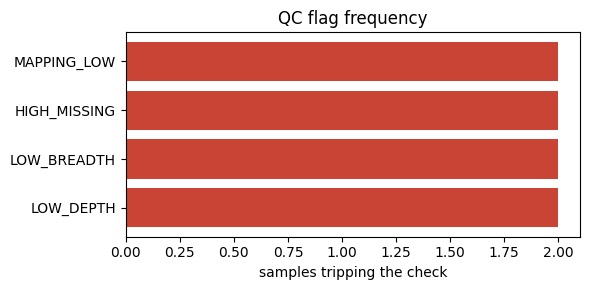

In [3]:
from collections import Counter
flags = pd.read_csv('example_outputs/samples_demo_flags.tsv', sep='\t')

print('verdicts:', dict(flags['verdict'].value_counts()))

# which samples failed, and why
failed = flags[flags['verdict'] == 'FAIL'][['sample', 'flags']]
print('\nfailed samples:')
print(failed.to_string(index=False))

# flag frequency across the cohort ('.' means no flag -> skip it)
freq = Counter(x for row in flags['flags'].dropna() for x in str(row).split(',') if x and x != '.')
if freq:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(list(freq.keys()), list(freq.values()), color='#C94434')
    ax.set_xlabel('samples tripping the check'); ax.set_title('QC flag frequency')
    plt.tight_layout(); plt.show()

### 5.3 Depth vs breadth (the QC scatter)

A quick way to spot the outliers: mean depth against genome breadth, coloured by verdict. Low-depth /
low-breadth samples sit in the bottom-left — exactly the ones flagged FAIL.

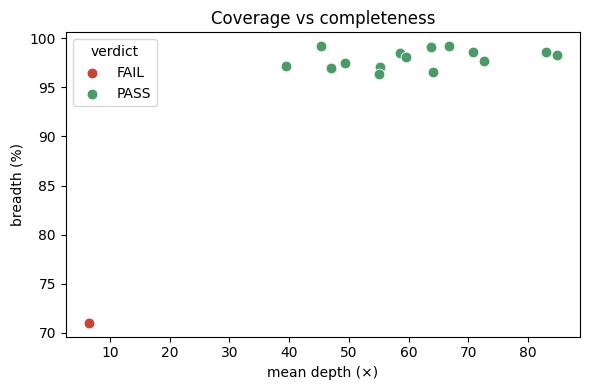

In [4]:
colour = {'PASS': '#4A9B68', 'WARN': '#D4C847', 'FAIL': '#C94434'}
m = summary.merge(flags[['sample', 'verdict']], left_on='sample_id', right_on='sample', how='left')

fig, ax = plt.subplots(figsize=(6, 4))
for v, grp in m.groupby('verdict'):
    ax.scatter(grp['mean_depth'], grp['breadth_pct'], s=60, label=v,
               color=colour.get(v, '#888'), edgecolor='white', linewidth=0.6)
ax.set_xlabel('mean depth (×)'); ax.set_ylabel('breadth (%)')
ax.set_title('Coverage vs completeness'); ax.legend(title='verdict')
plt.tight_layout(); plt.show()

### 5.4 Lineage composition

The cohort's MTBC lineages, drawn with the canonical *mycolorsTB* palette (the same colours the report
uses). With `--run_pathotypr` these come from alignment-free k-mer typing.

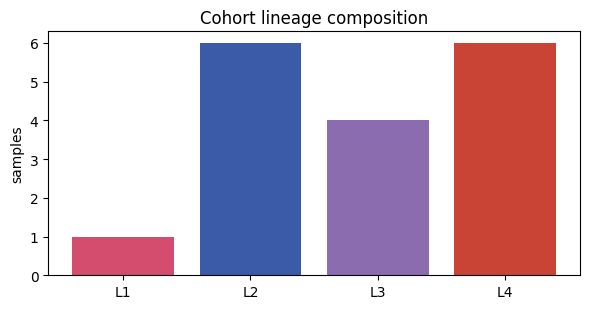

In [5]:
# canonical mycolorsTB lineage palette (subset)
MYCOLORS = {'L1':'#D44D6E','L2':'#3B5BA9','L3':'#8B6DAF','L4':'#C94434','L5':'#A07040',
            'L6':'#4A9B68','L7':'#D4C847','L8':'#B07AA1','L9':'#5CB85C','L10':'#7DA094'}

lin = summary['lineage'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(lin.index, lin.values, color=[MYCOLORS.get(l, '#888') for l in lin.index])
ax.set_ylabel('samples'); ax.set_title('Cohort lineage composition')
plt.tight_layout(); plt.show()

### 5.5 Drug resistance

`*_dr.tsv` holds the pathotypr WHO-catalogue calls (`--run_pathotypr`). Each row is a resistance
mutation with its drug, gene, HGVS mutation (H37Rv numbering), WHO grade, allele frequency and depth.
We pivot it into the **sample × drug** matrix the report shows, and flag MDR (RIF + INH).

In [6]:
dr = pd.read_csv('example_outputs/samples_demo_dr.tsv', sep='\t')
print(dr.shape[0], 'resistance calls across', dr['drug'].nunique(), 'drugs')
display(dr[['sample','drug','gene','mutation','grade','af','dp']].head())

# sample × drug resistance matrix (R where a WHO group-1/2 mutation is present)
matrix = (dr.assign(hit='R')
            .pivot_table(index='sample', columns='drug', values='hit', aggfunc='first')
            .fillna('·'))

# MDR = resistant to at least rifampicin AND isoniazid
mdr = [s for s in matrix.index if {'RIF','INH'}.issubset(set(dr[dr['sample'] == s]['drug']))]
print('MDR sample(s):', mdr or 'none')
matrix

13 resistance calls across 6 drugs


,sample,drug,gene,mutation,grade,af,dp
0,TB-P1-d180,INH,katG,p.Ser315Thr,1) Assoc w R,0.98,54
1,TB-P1-d180,RIF,rpoB,p.Ser450Leu,1) Assoc w R,0.95,52
2,TB-P1-d180,INH,inhA,c.-15C>T,1) Assoc w R,0.92,50
3,TB-P1-d120,INH,katG,p.Ser315Thr,1) Assoc w R,0.71,48
4,TB-2020-C,RIF,rpoB,p.Ser450Leu,1) Assoc w R,1.00,60


MDR sample(s): ['TB-P1-d180']


drug,EMB,FQ,INH,PZA,RIF,STR
sample,,,,,,
TB-2020-C,R,·,·,·,R,·
TB-2020-D,·,R,·,·,·,·
TB-2022-F,·,·,R,·,·,·
TB-P1-d120,·,·,R,·,·,·
TB-P1-d180,·,·,R,·,R,·
TB-P2-t1,·,·,·,R,·,·
TB-P2-t4,R,R,R,·,·,·
TB-P3-v3,·,·,·,·,·,R


### 5.6 The SNP matrix

`*_snp_matrix.tsv` is the master site × sample allele-frequency matrix (rows = variable SNP sites,
two columns per sample: `<sample>|AF` and `<sample>|DP`). It's the substrate for phylogenetics and
for the report's SNP-matrix heatmap; here we draw the allele-frequency heatmap directly.

19 SNP sites × 17 samples


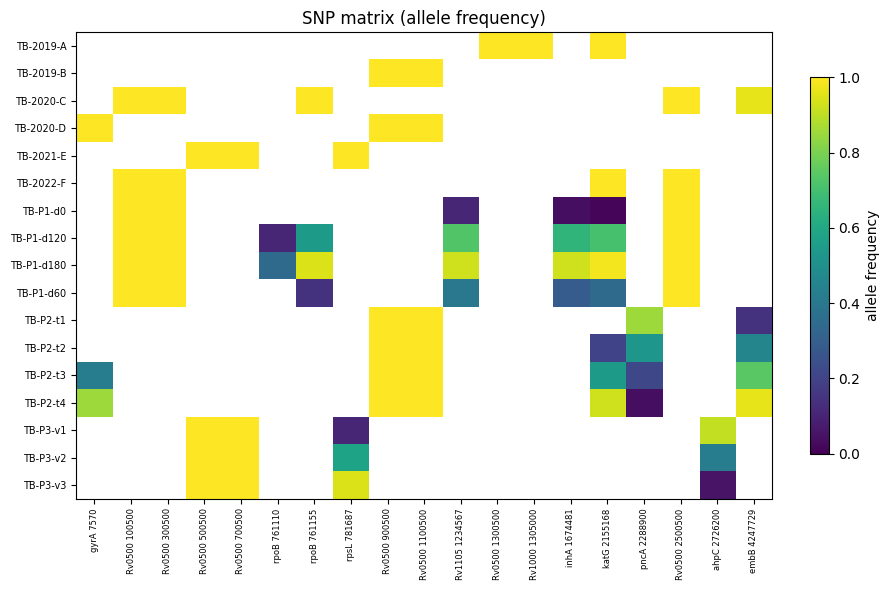

In [7]:
snpm = pd.read_csv('example_outputs/samples_demo_snp_matrix.tsv', sep='\t')
af = snpm[[c for c in snpm.columns if c.endswith('|AF')]]
af.columns = [c.replace('|AF', '') for c in af.columns]
print(snpm.shape[0], 'SNP sites ×', af.shape[1], 'samples')

site_lbl = (snpm['gene'].fillna(snpm['contig']).astype(str) + ' ' + snpm['pos'].astype(str))
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(af.T.astype(float).values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(site_lbl))); ax.set_xticklabels(site_lbl, rotation=90, fontsize=6)
ax.set_yticks(range(af.shape[1])); ax.set_yticklabels(af.columns, fontsize=7)
fig.colorbar(im, ax=ax, label='allele frequency', fraction=0.025)
ax.set_title('SNP matrix (allele frequency)'); plt.tight_layout(); plt.show()

## 6. The interactive QC report

Everything above (and much more — SNP dynamics over time, epistasis, taxonomic composition, the drug
resistance panel with gene→Mycobrowser links and dual H37Rv coordinate/amino-acid numbering) is folded
into a **single self-contained `*_qc_report.html`**. Open it in a browser — no server, no internet.
Tick samples into the exclusion basket and export `keep_list.txt` / `exclusion.tsv` for downstream
phylogeny. See [Interactive QC Report](../qc-report.md).

## Next steps

- [Configuration](../configuration.md) — every parameter and the feature-toggle overview
- [Lineage & drug-resistance typing](../pathotypr.md) — pathotypr, the k-mer coordinate liftover, blind-spot masking
- [Outputs](../outputs.md) — the full result tree

*The example cohort here is synthetic demo data; point the same code at your own run's
`results_bampiro/<samplesheet>_*.tsv` to analyse a real cohort.*